In [1]:
import Bio
import itertools
import random
from Bio import SeqIO

In [2]:
import pandas as pd
from Bio.Restriction import AllEnzymes

AllEnzymes

RestrictionBatch(['AanI', 'AarI', 'AasI', 'AatII', 'Aba6411II', 'AbaB8342IV', 'AbaCIII', 'AbaSI', 'AbaUMB2I', 'AbsI', 'Acc16I', 'Acc36I', 'Acc65I', 'Acc65V', 'AccB1I', 'AccB7I', 'AccBSI', 'AccI', 'AccII', 'AccIII', 'AceIII', 'AchA6III', 'AciI', 'AclI', 'AclWI', 'Aco12261II', 'AcoI', 'AcoY31II', 'AcsI', 'AcuI', 'AcvI', 'AcyI', 'AdeI', 'Adh6U21I', 'AfaI', 'AfeI', 'AfiI', 'AflII', 'AflIII', 'AgeI', 'AgsI', 'AhaIII', 'AhdI', 'AhlI', 'AhyRBAHI', 'AhyYL17I', 'AjiI', 'AjnI', 'AjuI', 'AleI', 'AlfI', 'AloI', 'AluBI', 'AluI', 'Alw21I', 'Alw26I', 'Alw44I', 'AlwFI', 'AlwI', 'AlwNI', 'Ama87I', 'AmaCSI', 'Aod1I', 'Aor13HI', 'Aor51HI', 'AoxI', 'ApaBI', 'ApaI', 'ApaLI', 'ApeKI', 'ApoI', 'ApyPI', 'AquII', 'AquIII', 'AquIV', 'ArsI', 'AscI', 'AseI', 'Asi256I', 'AsiGI', 'AsiSI', 'Asp103I', 'Asp114pII', 'Asp700I', 'Asp718I', 'AspA2I', 'AspBHI', 'AspDUT2V', 'AspJHL3II', 'AspLEI', 'AspNIH4III', 'AspS9I', 'AspSLV7III', 'Asu14238IV', 'AsuC2I', 'AsuHPI', 'AsuI', 'AsuII', 'AsuNHI', 'AteTI', 'AvaI', 'AvaII', 'Ava

In [3]:
"""
commerical available enzymes
not sensitive to 6mA or 5mC methylation
that the ovhg that can be compatible with the the sticky end from type IIs RE
do not have amybiguity recognation sequence

#good ligation activity after digestion


#accept standard digesting condition, 37C and with rCutSmart buffer

do not digest the outside MCS range of the plasmid

can be integrated into the insert animo acid sequence with slience mutation
can have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site

GC content or the hbond number in the sticky end


"""

'\ncommerical available enzymes\nnot sensitive to 6mA or 5mC methylation\nthat the ovhg that can be compatible with the the sticky end from type IIs RE\ndo not have amybiguity recognation sequence\n\n#good ligation activity after digestion\n\n\n#accept standard digesting condition, 37C and with rCutSmart buffer\n\ndo not digest the outside MCS range of the plasmid\n\ncan be integrated into the insert animo acid sequence with slience mutation\ncan have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site\n\nGC content or the hbond number in the sticky end\n\n\n'

In [4]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [5]:
from Bio.Restriction.Restriction_Dictionary import rest_dict
import numpy as np
import re
from Bio.Seq import Seq
import pandas as pd

In [6]:
def count_sticky_end_hbond(ovhgseq):
    """
    count the number of sticky end in the sequence
    :param seq: the sequence
    :param enzyme: the enzyme
    :return: the number of sticky end
    """
    if ovhgseq is None or len(ovhgseq) == 0:
        return 0
    else:
        a_count = ovhgseq.count("A")*2
        t_count = ovhgseq.count("T")*2
        g_count = ovhgseq.count("G")*3
        c_count = ovhgseq.count("C")*3
        return a_count + t_count + g_count + c_count

In [7]:
def methylation_check(enzyme):

    df_methylation_check = pd.read_csv('../utils/output/methylation_check.csv')

    dh5a_compatible = set(
        df_methylation_check.loc[~df_methylation_check['6mA_5mC_sensitive'], 'enzyme'].dropna().tolist() +
        df_methylation_check.loc[~df_methylation_check['6mA_5mC_sensitive'], 'prototype'].dropna().tolist()
    )

    if enzyme in dh5a_compatible:
        return True
    else:
        return False

In [8]:
def neb_check(enzyme):
    """
    check if the enzyme is in the neb list
    :param enzyme: the enzyme name
    :return: True if the enzyme is in the neb list, False otherwise
    """
    
    df_neb = pd.read_csv('./output/neb_buffer_activity_cleaned.csv')

    if not enzyme in df_neb['enzyme'].unique().tolist():
        return False
    
    if df_neb.loc[df_neb['enzyme'] == enzyme, 'ligation_efficiencies'].iloc[0] == "low":
        return False
    
    if df_neb.loc[df_neb['enzyme'] == enzyme, 'star_activity'].iloc[0] == True:
        return False

    return True

In [9]:
def merge_suppliers(suppliers):
    """Merge supplier lists/tuples into a sorted tuple."""
    return tuple(sorted(set().union(*suppliers)))

def merge_group(group):
    """Merge rows in a group."""
    return pd.Series({
        'name': "__".join(group['name']),
        'suppl': merge_suppliers(group['suppl']),
        **group.iloc[0].drop(['name', 'suppl'])
    })



In [12]:
df = pd.DataFrame(rest_dict).T
df = df[['ovhg', 'ovhgseq', 'site', 'size', 'suppl']]

df_neb = pd.read_csv('./output/neb_buffer_activity_cleaned.csv')
neb_name_list =  df_neb['enzyme'].unique().tolist()

df['name'] = df.index
df['elucidate'] = df.apply(lambda row: getattr(Bio.Restriction, row['name']).elucidate(), axis=1)

#df = df[
#        (df['suppl'].str.len() > 0) & 
#        (df.elucidate.str.match('^[ATCG^_]+$')) & 
#        (df.ovhg != 0)
#        ]

# Group and merge rows
#df = df.groupby(['ovhgseq', 'ovhg', 'site'], as_index=False).apply(merge_group).reset_index(drop=True)

# Simplify 'name' and set index
#df['isoschizomers'] = df['name']
#df['name'] = df['isoschizomers'].apply(lambda x: next((e for e in sorted(x.split("__")) if "N" in getattr(Bio.Restriction, e).suppl), x.split("__")[0]))
#df['name'] = df['isoschizomers'].apply(lambda x: next((e for e in sorted(x.split("__")) if e in neb_name_list), x.split("__")[0]))
#df.set_index('name', inplace=True)

df['methylation_check'] = df['name'].apply(methylation_check)
df['neb_check'] = df['name'].apply(neb_check)

df['stick_end_hbond_number'] = df['ovhgseq'].apply(lambda x: count_sticky_end_hbond(x))
df['palindromic'] = df['site'].apply(lambda seq: seq == str(Seq(seq).reverse_complement()))

df = df[
        (df['suppl'].str.len() > 0) & 
        (df.elucidate.str.match('^[ATCG^_]+$')) & 
        (df.ovhg != 0) &
        (df['methylation_check'] == True) &
        (df['neb_check'] == True)
        ]


In [13]:
df.shape

(46, 11)

In [14]:
df

,ovhg,ovhgseq,site,size,suppl,name,elucidate,methylation_check,neb_check,stick_end_hbond_number,palindromic
AatII,4,ACGT,GACGTC,6,"(B, I, K, M, N, V)",AatII,G_ACGT^C,True,True,10,True
AciI,-2,CG,CCGC,4,"(N,)",AciI,C^CG_C,True,True,6,False
AclI,-2,CG,AACGTT,6,"(I, N, V)",AclI,AA^CG_TT,True,True,6,True
AflII,-4,TTAA,CTTAAG,6,"(J, K, N)",AflII,C^TTAA_G,True,True,8,True
AgeI,-4,CCGG,ACCGGT,6,"(J, N, R)",AgeI,A^CCGG_T,True,True,12,True
ApaI,4,GGCC,GGGCCC,6,"(B, I, J, K, M, N, Q, R, S, V, X)",ApaI,G_GGCC^C,True,True,12,True
ApaLI,-4,TGCA,GTGCAC,6,"(C, K, N)",ApaLI,G^TGCA_C,True,True,10,True
AscI,-4,CGCG,GGCGCGCC,8,"(N,)",AscI,GG^CGCG_CC,True,True,12,True
AvrII,-4,CTAG,CCTAGG,6,"(N,)",AvrII,C^CTAG_G,True,True,10,True
BclI,-4,GATC,TGATCA,6,"(B, C, J, M, N, O, R, S)",BclI,T^GATC_A,True,True,10,True


In [15]:
# For non-palindromic REs, create a reverse complement row
non_pal = df[~df['palindromic']].copy()
non_pal['site'] = non_pal['site'].apply(lambda x: str(Seq(x).reverse_complement()))
non_pal['ovhgseq'] = non_pal['ovhgseq'].apply(lambda x: str(Seq(x).reverse_complement()))
non_pal['elucidate'] = non_pal['elucidate'].apply(lambda x: str(Seq(x).reverse_complement()))
#non_pal['name'] = non_pal['name'] + "_rc"

# Append the reverse complement rows to the original DataFrame

df['reverse_complement'] = df.apply(lambda x: False, axis=1)
non_pal['reverse_complement'] = non_pal.apply(lambda x: True, axis=1)
df = pd.concat([df, non_pal])

In [16]:
df.ovhg.value_counts()

-4    26
-2    11
 4     7
 2     4
Name: ovhg, dtype: int64

In [17]:
df.T

,AatII,AciI,AclI,AflII,AgeI,ApaI,ApaLI,AscI,AvrII,BclI,...,PvuI,SacI,SacII,SalI,SpeI,TaqI,XbaI,XhoI,AciI,BseYI
ovhg,4,-2,-2,-4,-4,4,-4,-4,-4,-4,...,2,4,2,-4,-4,-2,-4,-4,-2,-4
ovhgseq,ACGT,CG,CG,TTAA,CCGG,GGCC,TGCA,CGCG,CTAG,GATC,...,AT,AGCT,GC,TCGA,CTAG,CG,CTAG,TCGA,CG,CTGG
site,GACGTC,CCGC,AACGTT,CTTAAG,ACCGGT,GGGCCC,GTGCAC,GGCGCGCC,CCTAGG,TGATCA,...,CGATCG,GAGCTC,CCGCGG,GTCGAC,ACTAGT,TCGA,TCTAGA,CTCGAG,GCGG,GCTGGG
size,6,4,6,6,6,6,6,8,6,6,...,6,6,6,6,6,4,6,6,4,6
suppl,"(B, I, K, M, N, V)","(N,)","(I, N, V)","(J, K, N)","(J, N, R)","(B, I, J, K, M, N, Q, R, S, V, X)","(C, K, N)","(N,)","(N,)","(B, C, J, M, N, O, R, S)",...,"(B, K, M, N, O, Q, R, S, X)","(B, J, K, M, N, O, Q, R, S, X)","(B, J, K, N, O, Q, R, X)","(B, C, I, J, K, M, N, O, Q, R, S, V, X)","(B, J, K, M, N, O, Q, R, S, X)","(B, C, I, J, K, M, N, Q, R, S, V, X)","(B, C, I, J, K, M, N, Q, R, S, V, X)","(B, J, K, M, N, O, Q, R, S, X)","(N,)","(N,)"
name,AatII,AciI,AclI,AflII,AgeI,ApaI,ApaLI,AscI,AvrII,BclI,...,PvuI,SacI,SacII,SalI,SpeI,TaqI,XbaI,XhoI,AciI,BseYI
elucidate,G_ACGT^C,C^CG_C,AA^CG_TT,C^TTAA_G,A^CCGG_T,G_GGCC^C,G^TGCA_C,GG^CGCG_CC,C^CTAG_G,T^GATC_A,...,CG_AT^CG,G_AGCT^C,CC_GC^GG,G^TCGA_C,A^CTAG_T,T^CG_A,T^CTAG_A,C^TCGA_G,G_CG^G,G_CTGG^G
methylation_check,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
neb_check,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
stick_end_hbond_number,10,6,6,8,12,12,10,12,10,10,...,4,10,6,10,10,6,10,10,6,11


In [18]:
df.to_csv('../utils/output/available_restriction_enzyme.csv', index=False)

In [19]:
df = pd.read_csv('../utils/output/available_restriction_enzyme.csv')

In [20]:
"""
commerical available enzymes
not sensitive to 6mA or 5mC methylation
do not have amybiguity recognation sequence


can be integrated into the insert animo acid sequence with slience mutation
can have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site

GC content or the hbond number in the sticky end


"""

'\ncommerical available enzymes\nnot sensitive to 6mA or 5mC methylation\ndo not have amybiguity recognation sequence\n\n\ncan be integrated into the insert animo acid sequence with slience mutation\ncan have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site\n\nGC content or the hbond number in the sticky end\n\n\n'

In [21]:
def get_uncut_bases(text):
    """
    For a given enzyme site elucidation string that uses '^' and '_' as cut markers,
    return a list of indices of the uncut bases (i.e. bases that are not between a pair of markers).

    Each marker toggles the state of being within a cut region.
    
    If the enzyme name ends with '_rc', then the elucidation string is obtained
    from the enzyme with '_rc' removed, and the string is reversed with '^' and '_' swapped.
    
    Args:
        site (str): The enzyme name whose elucidation string is used.
        
    Returns:
        list: List of indices (in the cleaned sequence, with markers removed) for uncut bases.
    """

    #text == str(Seq(text).reverse_complement())
    """
    if site.endswith('_rc'):
        base_site = site[:-3]  # Remove the "_rc" suffix
        text = getattr(Bio.Restriction, base_site).elucidate()
        # Reverse the text and swap '^' with '_' and vice versa
        swapped_text = []
        for ch in text[::-1]:
            if ch == '^':
                swapped_text.append('_')
            elif ch == '_':
                swapped_text.append('^')
            else:
                complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
                swapped_text.append(complement.get(ch, ch))
        text = ''.join(swapped_text)
    else:
        text = getattr(Bio.Restriction, site).elucidate()
        text = Seq(text).reverse_complement()
    """

    indices = []
    clean_idx = 0  # index in the cleaned text (ignoring marker characters)
    in_marker = False
    markers = {'^', '_'}
    
    for ch in text:
        if ch in markers:
            in_marker = not in_marker
        else:
            if not in_marker:
                indices.append(clean_idx)
            clean_idx += 1
    return indices




In [22]:
# Create a DataFrame with rc column from unique_RE_sites list
nucleotides = ['A', 'T', 'G', 'C']
df_explode = df.copy()
df_explode['snp'] = df_explode.apply(lambda row: nucleotides, axis=1)
df_explode['snp_index'] = df_explode.apply(lambda row: get_uncut_bases(row['elucidate']), axis=1)
df_explode['frame_shift'] = df_explode.apply(lambda row: list(range(10-row['size'])), axis=1)
df_explode['padding_bp'] = df_explode.apply(lambda row: [''.join(seq) for seq in itertools.product(nucleotides, repeat=9-int(row['size']))], axis=1)


In [23]:
# Explode the DataFrame for all combinations
df_exploded = df_explode.explode('snp')
df_exploded = df_exploded.explode('snp_index')
df_exploded = df_exploded.explode('frame_shift')
df_exploded = df_exploded.explode('padding_bp')

# Reset the index to have clean row numbers
df_exploded = df_exploded.reset_index(drop=True)

In [24]:
df_exploded.shape

(412224, 16)

In [25]:
def create_mutant(row):

    # Check if mutation_index is NaN
    if np.isnan(row['snp_index']):
        return row['site']
    
    rc_seq = list(row['site'])  # Convert string to list to make it mutable
    mutation_index = int(row['snp_index'])
        
    # Replace character at mutation index with new nucleotide
    rc_seq[mutation_index] = row['snp']
    
    return ''.join(rc_seq)  # Convert back to string

# Add the new column with mutated sequences
df_exploded['site_mutate'] = df_exploded.apply(create_mutant, axis=1)

In [26]:
df_exploded.ovhg.value_counts()

-2    270336
 2     57536
-4     49408
 4     34944
Name: ovhg, dtype: int64

In [27]:
def get_frame_shifted(row, column_name):
    # Get the frame shift value
    re_site_seq = row[column_name]
    # Get the 3bp sequence
    three_bp_seq = row['padding_bp']
    # Get the frame shift value
    frame_shift = row['frame_shift']

    shifted_re_site_seq = three_bp_seq[:frame_shift]+ re_site_seq + three_bp_seq[frame_shift:]

    return shifted_re_site_seq

df_exploded['re_9bp_site'] = df_exploded.apply(lambda row: get_frame_shifted(row, 'site'), axis=1)
df_exploded['re_9bp_site_mutated'] = df_exploded.apply(lambda row: get_frame_shifted(row, 'site_mutate'), axis=1)

In [28]:
df_exploded.shape

(412224, 19)

In [29]:
df_exploded['re_3aa_site'] = df_exploded['re_9bp_site'].apply(lambda x: str(Seq(x).translate()))
df_exploded['re_3aa_site_mutated'] = df_exploded['re_9bp_site_mutated'].apply(lambda x: str(Seq(x).translate()))

In [30]:
def get_codon_usage(sequence, codon_usage_dict):
    """
    Calculate the average codon usage frequency of a given DNA sequence based on the E. coli codon usage table.

    Args:
        sequence (str): DNA sequence (must be divisible by 3).

    Returns:
        float: The average codon usage frequency of the sequence.
    """
    # Ensure the sequence length is divisible by 3
    if len(sequence) % 3 != 0:
        raise ValueError("The input sequence length must be divisible by 3.")

    codon_list = [sequence[i:i+3] for i in range(0, len(sequence), 3)]
    codon_frequency = [codon_usage_dict[codon] for codon in codon_list if codon in codon_usage_dict]
    codon_usage = sum(codon_frequency) / len(codon_list)
    return codon_usage


In [31]:
codon_usage_df = pd.read_csv('../utils/output/codon_usage.csv')
codon_usage_dict = dict(zip(codon_usage_df['codon'], codon_usage_df['frequency']))

df_exploded['codon_usage'] = df_exploded['re_9bp_site'].apply(lambda x: get_codon_usage(x, codon_usage_dict))
df_exploded['codon_usage_mutated'] = df_exploded['re_9bp_site_mutated'].apply(lambda x: get_codon_usage(x, codon_usage_dict))

In [33]:
df_seamless_insert = df_exploded[
    (~df_exploded['re_3aa_site'].str.contains(r'\*'))
]

df_seamless_insert = df_seamless_insert.loc[
    df_seamless_insert.groupby(['name', 're_3aa_site'])['codon_usage'].idxmax()
]

# Remove specified columns from df_seamless_insert
columns_to_remove = ['reverse_complement', 'snp', 'snp_index', 'padding_bp', 'suppl', 'methylation_check', 'neb_check',
                     'site_mutate', 're_9bp_site_mutated', 're_3aa_site_mutated', 'codon_usage', 'codon_usage_mutated', 'palindromic']
df_seamless_insert = df_seamless_insert.drop(columns=columns_to_remove)

In [34]:
df_seamless_insert.shape

(8512, 10)

In [35]:
df_seamless_insert.to_csv('../utils/output/seamless_insert.csv', index=False)
df_seamless_insert = pd.read_csv('../utils/output/seamless_insert.csv')

In [37]:
df_slient_mutation = df_exploded[
    (df_exploded['re_9bp_site'] != df_exploded['re_9bp_site_mutated']) &
    (df_exploded['re_3aa_site'] == df_exploded['re_3aa_site_mutated']) &
    (df_exploded['ovhg'].isin([-5,-4,-3,2,-2])) &
    (~df_exploded['re_3aa_site'].str.contains(r'\*'))
]

df_slient_mutation = df_slient_mutation.loc[
    df_slient_mutation.groupby(['name', 're_3aa_site'])['codon_usage_mutated'].idxmax()
]

# Remove specified columns from df_seamless_insert
columns_to_remove = ['reverse_complement', 'snp', 'snp_index', 'padding_bp', 'suppl', 'methylation_check', 'neb_check',
                     'site_mutate', 'codon_usage', 'codon_usage_mutated','re_3aa_site_mutated', 'palindromic']
df_slient_mutation = df_slient_mutation.drop(columns=columns_to_remove)

In [38]:
df_slient_mutation.to_csv('../utils/output/slient_mutation.csv', index=False)
df_slient_mutation = pd.read_csv('../utils/output/slient_mutation.csv')

In [39]:
len(df_slient_mutation.re_3aa_site.unique())

2175

In [72]:
df_seamless_insert_2 = df_seamless_insert.loc[
    df_seamless_insert.groupby(['name', 're_9bp_site'])['codon_usage'].idxmax()
]

In [73]:
df_seamless_insert_2.sample(5).T

,30965,547037,43181,96651,294208
name,HindIII,Csp6I,BstKTI,NlaIII,Hin6I
suppl,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...","('B', 'I')","('I',)","('B', 'I', 'N', 'R')","('B',)"
ovhg,-4,-2,2,4,-2
ovhgseq,AGCT,TA,AT,CATG,CG
site,AAGCTT,GTAC,GATC,CATG,GCGC
size,6,4,4,4,4
elucidate,A^AGCT_T,G^TA_C,G_AT^C,_CATG^,G^CG_C
isoschizomers,HindIII,Csp6I__RsaNI,BstKTI,FaeI__Hin1II__Hsp92II__NlaIII,Hin6I
stick_end_hbond_number,10,4,4,10,6
palindromic,True,True,True,True,True


In [ ]:
reverse_complement, snp, snp_index, padding_bp, site_mutate, re_9bp_site_mutated, codon_usage, codon_usage_mutate

In [ ]:

columns = ['name', 'ovhg','ovhgseq','site','size','suppl','elucidate',
 'stick_end_hbond_number','palindromic','re_site_shifted',
 're_site_shifted_tl','frame_shift', 'codon_usage','isoschizomers']

df_seamless_insert_2 = df_seamless_insert[columns]

In [127]:
df_seamless_insert_2 = df_seamless_insert_2.loc[
    df_seamless_insert_2.groupby(['name', 're_site_shifted_tl'])['codon_usage'].idxmax()
]

df_seamless_insert_2.to_csv('../utils/output/restriction_enzyme_seamless_insert.csv', index=False)

In [128]:
df_slient_mutation.columns

Index(['ovhg', 'ovhgseq', 'site', 'size', 'suppl', 'name', 'elucidate',
       'stick_end_hbond_number', 'palindromic', 'isoschizomers',
       'reverse_complement', 'snp', 'snp_index', 'frame_shift', 'padding_bp',
       'site_mutate', 're_site_shifted', 're_site_mutate_shifted',
       're_site_shifted_tl', 're_site_mutate_shifted_tl', 'codon_usage',
       'codon_usage_mutate'],
      dtype='object')

In [ ]:
columns = ['name', 'ovhg','ovhgseq','site','size','suppl','elucidate',
 'stick_end_hbond_number','palindromic','re_site_shifted', 're_site_mutate_shifted',
 're_site_shifted_tl','frame_shift', 'codon_usage_mutate','isoschizomers']

df_slient_mutation_2 = df_slient_mutation[columns]

df_slient_mutation_2 = df_slient_mutation_2.loc[
    df_slient_mutation_2.groupby(['name', 're_site_shifted_tl'])['codon_usage_mutate'].idxmax()
]

df_slient_mutation_2.to_csv('../utils/output/restriction_enzyme_slient_mutation.csv', index=False)

In [146]:
len(df_seamless_insert_2.site.unique())

67

In [150]:
df_slient_mutation_2[df_slient_mutation_2.stick_end_hbond_number>=8].ovhg.unique()

array([-4])

In [199]:
fidelity_file = '../utils/input/golden_gate_fidelity/FileS03_T4_18h_25C.xlsx'
df_fidelity = pd.read_excel(fidelity_file)
df_fidelity.index = df_fidelity['Overhang']

In [200]:
df_fidelity

,Overhang,AAAA,AAAC,AAAG,AAAT,AACA,AACC,AACG,AACT,AAGA,...,TTCG,TTCT,TTGA,TTGC,TTGG,TTGT,TTTA,TTTC,TTTG,TTTT
Overhang,,,,,,,,,,,,,,,,,,,,,
TTTT,TTTT,3804,4,96,57,0,0,1,1,5,...,0,0,0,0,0,0,1,0,0,0
GTTT,GTTT,2,5322,3,565,1,44,2,6,0,...,0,0,0,0,0,0,0,2,0,0
CTTT,CTTT,3,2,4742,3,1,0,59,0,0,...,0,0,0,0,0,0,0,0,1,0
ATTT,ATTT,1,3,2,5152,0,0,0,5,0,...,0,0,0,0,0,0,0,0,0,0
TGTT,TGTT,0,0,0,0,5482,11,768,322,5,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACAA,ACAA,0,0,0,0,0,0,0,0,0,...,0,1,4,9,31,4798,1,0,0,1
TAAA,TAAA,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1440,1,28,31
GAAA,GAAA,0,0,0,0,0,0,0,0,0,...,0,1,2,1,0,1,3,5444,3,18


In [201]:
# Accessing the value where row index is "AATT" and column name is "CCGG"
fidelity_value = df_fidelity.loc["AAGA", "TTTT"]
print(fidelity_value)

5


In [202]:
fidelity_value = df_fidelity.loc["TTTT", "AAGA"]
print(fidelity_value)

5


In [203]:
sticky_end = [''.join(seq) for seq in itertools.product(nucleotides, repeat=4)]

In [204]:
# Create a list to store the results
fidelity_results = []

# Iterate over all sticky ends
for sticky_end in df_fidelity.index:
    # Get the reverse complement of the sticky end
    reverse_complement = str(Seq(sticky_end).reverse_complement())
    
    # Check if the reverse complement exists in the columns of df_fidelity
    if reverse_complement in df_fidelity.columns:
        # Get the fidelity value
        fidelity_value = df_fidelity.loc[sticky_end, reverse_complement]
        # Append the result as a tuple
        fidelity_results.append((sticky_end, reverse_complement, fidelity_value))

# Convert the results to a DataFrame
df_fidelity_results = pd.DataFrame(fidelity_results, columns=['Sticky_End', 'Reverse_Complement', 'Fidelity_Value'])

df_fidelity_results['sticky_end_hbond'] = df_fidelity_results['Sticky_End'].apply(lambda x: count_sticky_end_hbond(x))


# Display the resulting DataFrame
print(df_fidelity_results)

    Sticky_End Reverse_Complement  Fidelity_Value  sticky_end_hbond
0         TTTT               AAAA            3804                 8
1         GTTT               AAAC            5322                 9
2         CTTT               AAAG            4742                 9
3         ATTT               AAAT            5152                 8
4         TGTT               AACA            5482                 9
..         ...                ...             ...               ...
251       ACAA               TTGT            4798                 9
252       TAAA               TTTA            1440                 8
253       GAAA               TTTC            5444                 9
254       CAAA               TTTG            4473                 9
255       AAAA               TTTT            3804                 8

[256 rows x 4 columns]


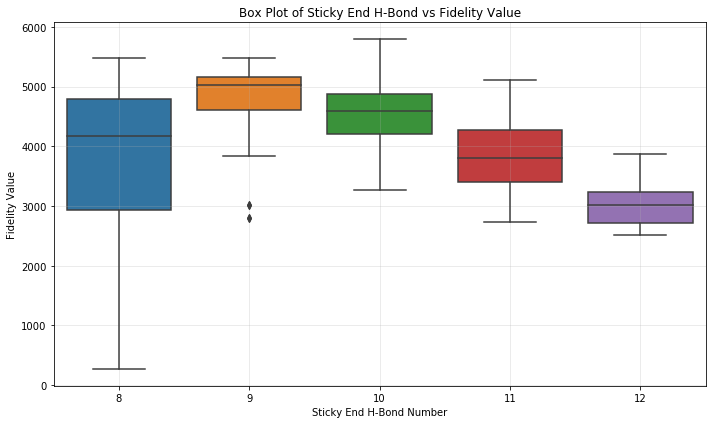

In [206]:
import seaborn as sns

import matplotlib.pyplot as plt

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sticky_end_hbond', y='Fidelity_Value', data=df_fidelity_results)

# Add labels and title
plt.xlabel('Sticky End H-Bond Number')
plt.ylabel('Fidelity Value')
plt.title('Box Plot of Sticky End H-Bond vs Fidelity Value')
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

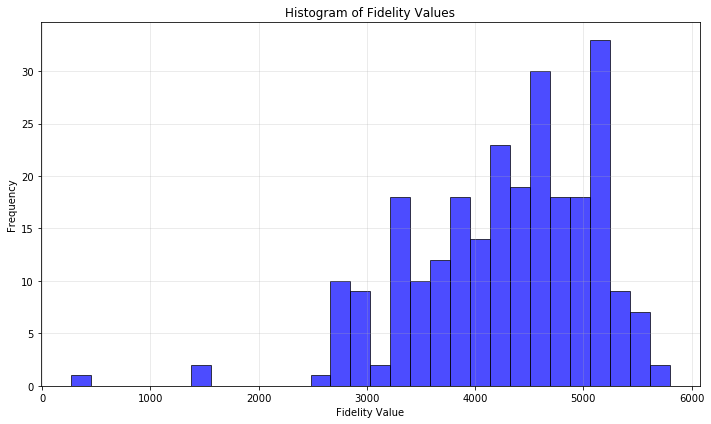

In [207]:
# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df_fidelity_results['Fidelity_Value'], bins=30, color='blue', alpha=0.7, edgecolor='black')

# Add labels and title
plt.xlabel('Fidelity Value')
plt.ylabel('Frequency')
plt.title('Histogram of Fidelity Values')
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

In [208]:
df_fidelity_results[df_fidelity_results.Fidelity_Value<3000].Sticky_End

42     CCCT
85     GGGG
87     AGGG
93     GAGG
101    GGCG
102    CGCG
138    CCTC
165    GGCC
166    CGCC
170    CCCC
192    TTTA
204    TATA
208    TTGA
240    TTAA
248    TCAA
252    TAAA
Name: Sticky_End, dtype: object

In [209]:
df_seamless_insert_2

,name,ovhg,ovhgseq,site,size,suppl,elucidate,stick_end_hbond_number,palindromic,re_site_shifted,re_site_shifted_tl,frame_shift,codon_usage,isoschizomers
0,EcoRI,-4,AATT,GAATTC,6,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...",G^AATT_C,8,True,GAATTCAAA,EFK,0,30.633333,EcoRI
1,EcoRI,-4,AATT,GAATTC,6,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...",G^AATT_C,8,True,GAATTCAAT,EFN,0,26.866667,EcoRI
2,EcoRI,-4,AATT,GAATTC,6,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...",G^AATT_C,8,True,GAATTCAAG,EFK,0,23.600000,EcoRI
3,EcoRI,-4,AATT,GAATTC,6,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...",G^AATT_C,8,True,GAATTCAAC,EFN,0,27.700000,EcoRI
4,EcoRI,-4,AATT,GAATTC,6,"('B', 'C', 'I', 'J', 'K', 'M', 'N', 'O', 'Q', ...",G^AATT_C,8,True,GAATTCATA,EFI,0,20.800000,EcoRI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711547,BbvCI,-3,TGA,GCTGAGG,7,"('N',)",GC_TGA^GG,7,False,GCGCTGAGG,ALR,2,29.000000,BbvCI
711548,BbvCI,-3,TGA,GCTGAGG,7,"('N',)",GC_TGA^GG,7,False,CAGCTGAGG,QLR,2,25.400000,BbvCI
711549,BbvCI,-3,TGA,GCTGAGG,7,"('N',)",GC_TGA^GG,7,False,CTGCTGAGG,LLR,2,31.800000,BbvCI
711550,BbvCI,-3,TGA,GCTGAGG,7,"('N',)",GC_TGA^GG,7,False,CGGCTGAGG,RLR,2,17.533333,BbvCI


In [131]:
columns = ['name', 'ovhg',
 'ovhgseq',
 'site',
 'size',
 'suppl',
 'elucidate',
 'stick_end_hbond_number',
 'palindromic','re_site_shifted','re_site_shifted_tl','frame_shift', 'codon_usage','isoschizomers']

df_seamless_insert_2 = df_seamless_insert[columns]

In [132]:
len(df_slient_mutation.re_site_shifted_tl.unique())
#len(df_no_slient_mutation.re_site_shifted_tl.unique())

3322

In [ ]:
df_slient_mutation['sticky_end_length'] = df_slient_mutation['ovhg'].apply(lambda x: abs(x))
df_slient_mutation['re_name'] = df_slient_mutation['name'].apply(lambda x: x.strip('_rc'))
df_slient_mutation['stick_end_hbond_number'] = df_slient_mutation['ovhgseq'].apply(lambda x: x.count("A")*2+x.count("T")*2+x.count("G")*3+x.count("C")*3)

In [ ]:
df_slient_mutation

In [ ]:
def new_func():
    # Group by enzyme name, calculating number of unique re_site_shifted_tl and taking the first ovhg value
    agg = df_slient_mutation.groupby("re_name").agg(
        count=("re_site_shifted_tl", "nunique"),
        sticky_end_length=("sticky_end_length", "first")
    ).reset_index()
    
    # Sort the data by the count for a cleaner plot
    agg = agg.sort_values("count", ascending=False)
    
    plt.figure(figsize=(8, 10))
    sns.barplot(data=agg, x="count", y="re_name", hue="sticky_end_length", dodge=False)
    plt.xlabel("Unique re_site_shifted_tl Count")
    plt.ylabel("Enzyme")
    plt.title("Unique re_site_shifted_tl Count per RE")
    plt.tight_layout()
    plt.show()

new_func()

In [ ]:
def new_func():
    # Group by enzyme name, calculating number of unique re_site_shifted_tl and taking the first ovhg value
    agg = df_slient_mutation.groupby("re_name").agg(
        count=("re_site_shifted_tl", "nunique"),
        stick_end_hbond_number=("stick_end_hbond_number", "first")
    ).reset_index()
    
    # Sort the data by the count for a cleaner plot
    agg = agg.sort_values("count", ascending=False)
    
    plt.figure(figsize=(8, 10))
    sns.barplot(data=agg, x="count", y="re_name", hue="stick_end_hbond_number", dodge=False)
    plt.xlabel("Unique re_site_shifted_tl Count")
    plt.ylabel("Enzyme")
    plt.title("Unique re_site_shifted_tl Count per RE")
    plt.tight_layout()
    plt.show()

new_func()

In [ ]:
df_slient_mutation.sample(1).T

In [ ]:
df_slient_mutation.to_csv("./output/df_slient_mutation.csv", index=False)

In [ ]:
df_slient_mutation.columns

In [ ]:
re_pet2a8a = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_start_codon = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)_start_codon'] == True)
].re_site_shifted_tl.unique().tolist()

re_pgex = df_slient_mutation[
    (df_slient_mutation['pGEX-4T-1'] == True)
].re_site_shifted_tl.unique().tolist()

re_pmal = df_slient_mutation[
    (df_slient_mutation['pMAL-c5X'] == True)
].re_site_shifted_tl.unique().tolist()

re_puc = df_slient_mutation[
    (df_slient_mutation['pUC18'] == True)
].re_site_shifted_tl.unique().tolist()

re_pqe = df_slient_mutation[
    (df_slient_mutation['pQE-3'] == True)
].re_site_shifted_tl.unique().tolist()

re_pcold = df_slient_mutation[
    (df_slient_mutation['pCold_I'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet21a = df_slient_mutation[
    (df_slient_mutation['pET-21a(+)'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_4hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=4)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_6hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=6)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_8hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=8)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_10hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=10)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_12hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=12)
].re_site_shifted_tl.unique().tolist()



In [ ]:
unique_3mer_list_w_slient_mutation = list(df_slient_mutation.re_site_shifted_tl.unique())

In [ ]:
def re_to_aa_with_slient_mutation_inactivate(seq):
    """
    Convert a nucleotide sequence to an amino acid sequence.
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]
    two_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=2)]

    mutated_re = [i[0]+seq[1:-1]+i[1] for i in two_bp_sequences]
    mutated_re = [i for i in mutated_re if i != seq]


    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]
    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]
    
    seq_ex = [seq] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2

    #print(seq_ex)

    aa_result = [Seq(i).translate() for i in seq_ex]
    aa_result = [str(i) for i in aa_result]
    aa_result = [i for i in aa_result if "*" not in i]
    aa_result = sorted(list(set(aa_result)))

    return aa_result

In [ ]:
aa_list = []

for re in unique_RE_sites:
    re_rc = str(Seq(re).reverse_complement())
    aa_list = aa_list + re_to_aa(re) + re_to_aa(re_rc)

In [ ]:
unique_aa_list  = list(set(aa_list))
aa_2mer_list = [i for i in unique_aa_list if len(i) == 2]
aa_3mer_list = [i for i in unique_aa_list if len(i) == 3]

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'
aa_2mer_to_3mer_list = []
for aa_2mer in aa_2mer_list:
    for aa in aa_str:
        aa_2mer_to_3mer_list.append(aa_2mer + aa)
        aa_2mer_to_3mer_list.append(aa+aa_2mer)

In [ ]:
unique_3mer_list  = list(set(aa_3mer_list + aa_2mer_to_3mer_list))

In [ ]:
len(unique_3mer_list)

In [ ]:
import random

def generate_random_aa_seq(length):
    """
    Generate a random amino acid sequence of specified length using amino acids from aa_str.
    
    Args:
        length (int): The desired length of the amino acid sequence
        
    Returns:
        str: A random amino acid sequence
    """
    # Generate random sequence by selecting from aa_str
    random_seq = ''.join(random.choice(aa_str) for _ in range(length))
    
    return random_seq

In [ ]:
def check_3mer_in_sequence(sequence, three_mer_list):
    """
    Check if any 3-mer from the list is present in the sequence.
    
    Args:
        sequence (str): The amino acid sequence to check
        three_mer_list (list): List of 3-mer amino acid sequences
        
    Returns:
        bool: True if any 3-mer is found in the sequence, False otherwise
    """
    for three_mer in three_mer_list:
        if three_mer in sequence:
            return True
    return False

In [ ]:
unique_3mer_list_w_slient_mutation

In [ ]:
def check_3mer_in_sequence(sequence, unique_3mer_list_w_slient_mutation):
    """
    Check if any 3-mer from the list is present in the sequence.
    
    Args:
        sequence (str): The amino acid sequence to check
        three_mer_list (list): List of 3-mer amino acid sequences
        
    Returns:
        bool: True if any 3-mer is found in the sequence, False otherwise
    """
    for three_mer in unique_3mer_list_w_slient_mutation:
        if three_mer in sequence:
            return True
    return False

In [ ]:
def calculate_3mer_probability(seq_length, list_3mer, test_num=1000):
    """
    Calculate the probability of finding any 3-mer from unique_3mer_list in random sequences.
    
    Args:
        seq_length (int): Length of random sequences to generate
        test_num (int): Number of test sequences to generate (default: 1000)
    
    Returns:
        float: Probability (percentage) of sequences containing any 3-mer from the list
    """
    # Counter for sequences containing 3-mers
    count = 0
    
    # Generate and test random sequences
    for _ in range(test_num):
        # Generate random sequence
        random_seq = generate_random_aa_seq(seq_length)
        random_seq = random_seq + random_seq[0:2]
        
        # Check if sequence contains any 3-mer from the list
        if check_3mer_in_sequence(random_seq, list_3mer):
            count += 1
    
    # Calculate probability as percentage
    probability = (count / test_num) * 100
    
    print(f"Sequences tested: {test_num}")
    print(f"Sequences with 3-mers: {count}")
    print(f"Probability: {probability:.2f}%")
    
    return probability

In [ ]:
def calculate_multiple_3mer_probabilities(seq_length_list, list_3mer, test_num=1000):
    """
    Calculate 3-mer probabilities for multiple sequence lengths.
    
    Args:
        seq_length_list (list): List of sequence lengths to test
        test_num (int): Number of test sequences for each length (default: 1000)
    
    Returns:
        pandas.DataFrame: DataFrame containing sequence lengths and their corresponding probabilities
    """
    # Create lists to store results
    lengths = []
    probabilities = []
    
    # Calculate probability for each sequence length
    for seq_length in seq_length_list:
        prob = calculate_3mer_probability(seq_length, list_3mer, test_num)
        lengths.append(seq_length)
        probabilities.append(prob)
    
    # Create DataFrame
    results_df = pd.DataFrame({
        'Sequence_Length': lengths,
        'Probability': probabilities
    })
    
    return results_df

In [ ]:
test_num = 1000

hurdler_pet2a8a = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a,test_num=test_num)
hurdler_pet2a8a_start_codon = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_start_codon,test_num=test_num)
hurdler_pgex = calculate_multiple_3mer_probabilities(range(4,51), re_pgex,test_num=test_num)
hurdler_pmal = calculate_multiple_3mer_probabilities(range(4,51), re_pmal,test_num=test_num)
hurdler_puc = calculate_multiple_3mer_probabilities(range(4,51), re_puc,test_num=test_num)
hurdler_pqe = calculate_multiple_3mer_probabilities(range(4,51), re_pqe,test_num=test_num)
hurdler_pcold = calculate_multiple_3mer_probabilities(range(4,51), re_pcold,test_num=test_num)
hurdler_pet21a = calculate_multiple_3mer_probabilities(range(4,51), re_pet21a,test_num=test_num)
hurdler_pet2a8a_4hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_4hbond,test_num=test_num)
hurdler_pet2a8a_6hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_6hbond,test_num=test_num)
hurdler_pet2a8a_8hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_8hbond,test_num=test_num)
hurdler_pet2a8a_10hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_10hbond,test_num=test_num)
hurdler_pet2a8a_12hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_12hbond,test_num=test_num)

In [ ]:
import os

# Create output directory if it doesn't exist
output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the restriction enzyme analysis dataframes
df_slient_mutation.to_csv(os.path.join(output_dir, "df_silent_mutation.csv"), index=False)
true_counts_df.to_csv(os.path.join(output_dir, "true_counts_df.csv"), index=False)

# Save the HURDLER probability dataframes
hurdler_dataframes = {
    "hurdler_pet28a": hurdler_pet2a8a,
    "hurdler_pet28a_start_codon": hurdler_pet2a8a_start_codon,
    "hurdler_pgex": hurdler_pgex,
    "hurdler_pmal": hurdler_pmal,
    "hurdler_puc": hurdler_puc,
    "hurdler_pqe": hurdler_pqe,
    "hurdler_pcold": hurdler_pcold,
    "hurdler_pet21a": hurdler_pet21a,
    "hurdler_pet28a_4hbond": hurdler_pet2a8a_4hbond,
    "hurdler_pet28a_6hbond": hurdler_pet2a8a_6hbond,
    "hurdler_pet28a_8hbond": hurdler_pet2a8a_8hbond,
    "hurdler_pet28a_10hbond": hurdler_pet2a8a_10hbond,
    "hurdler_pet28a_12hbond": hurdler_pet2a8a_12hbond
}

# Save each HURDLER dataframe
for name, df in hurdler_dataframes.items():
    df.to_csv(os.path.join(output_dir, f"{name}.csv"), index=False)

print(f"Successfully saved {len(hurdler_dataframes) + 2} files to {output_dir}/ directory")

In [ ]:
from matplotlib import pyplot as plt


plt.figure(figsize=(8, 4))

# List of plasmid probability DataFrames (excluding those ending with hbond)
plasmid_data = [
    (hurdler_pet2a8a, "pET-28a(+)"),
    (hurdler_pet2a8a_start_codon, "pET-28a(+)_start_codon"),
    (hurdler_pgex, "pGEX-4T-1"),
    (hurdler_pmal, "pMAL-c5X"),
    (hurdler_puc, "pUC18"),
    (hurdler_pqe, "pQE-3"),
    (hurdler_pcold, "pCold_I"),
    (hurdler_pet21a, "pET-21a(+)"),
]

# Plot each plasmid's probability vs sequence length
for data, label in plasmid_data:
    plt.plot(data['Sequence_Length'], data['Probability'],
             marker='o', label=label)

plt.xlabel('Sequence Length')
plt.ylabel('Probability (%)')
plt.title('3-mer Probability vs Sequence Length')
plt.legend(title="Plasmid")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(hurdler_pet2a8a_4hbond['Sequence_Length'], hurdler_pet2a8a_4hbond['Probability'],
         marker='o', label='≥4 H-bonds')
plt.plot(hurdler_pet2a8a_6hbond['Sequence_Length'], hurdler_pet2a8a_6hbond['Probability'],
         marker='o', label='≥6 H-bonds')
plt.plot(hurdler_pet2a8a_8hbond['Sequence_Length'], hurdler_pet2a8a_8hbond['Probability'],
         marker='o', label='≥8 H-bonds')
plt.plot(hurdler_pet2a8a_10hbond['Sequence_Length'], hurdler_pet2a8a_10hbond['Probability'],
         marker='o', label='≥10 H-bonds')
plt.plot(hurdler_pet2a8a_12hbond['Sequence_Length'], hurdler_pet2a8a_12hbond['Probability'],
         marker='o', label='12 H-bonds')

plt.xlabel('Sequence Length')
plt.ylabel('Probability (%)')
plt.title('3-mer Probability vs Sequence Length for pET-28a(+)')
plt.legend(title='Hydrogen Bond Threshold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from Bio.Seq import Seq

# Example DNA sequence
dna_seq = "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"

# Create a Seq object
coding_dna = Seq(dna_seq)

# Translate to protein
protein_seq = coding_dna.translate()

print(f"DNA sequence: {dna_seq}")
print(f"Protein sequence: {protein_seq}")

In [ ]:
from Bio.Seq import Seq

def get_sequence_and_reverse_complement(sequence):
    # Convert to Seq object if input is string
    if isinstance(sequence, str):
        sequence = Seq(sequence)
    
    # Get reverse complement
    reverse_comp = sequence.reverse_complement()
    
    # Return both sequences in a list
    return [str(sequence), str(reverse_comp)]

# Example usage
test_seq = "ACCTGC"
result = get_sequence_and_reverse_complement(test_seq)
print(f"Original sequence (5' to 3'): {result[0]}")
print(f"Reverse complement (5' to 3'): {result[1]}")


In [ ]:
import itertools
# Generate all possible 3-bp DNA sequences
nucleotides = ['A', 'T', 'G', 'C']
three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]

print(f"Total number of 3-bp sequences: {len(three_bp_sequences)}")
print("First 10 sequences:", len(three_bp_sequences))


In [ ]:
def re_to_aa(seq):
    """
    Convert a nucleotide sequence to an amino acid sequence.
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]


    # Create a Seq object
    seq_rc = str(Seq(seq).reverse_complement())

    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]
    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_1 = [i[0]+seq_rc+i[1]+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_2 = [i[0]+i[1]+seq_rc+i[2] for i in three_bp_sequences]

    
    seq_ex = [seq, seq_rc] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2 + seq_rc_ex_frame_shift_1 + seq_rc_ex_frame_shift_2

    print(seq_ex)

    aa_result = [Seq(i).translate() for i in seq_ex]
    aa_result = [str(i) for i in aa_result]
    aa_result = [i for i in aa_result if "*" not in i]
    aa_result = sorted(list(set(aa_result)))

    return aa_result





In [ ]:
aa_list = re_to_aa("ACCTGC")

len(aa_list)

In [ ]:
str(aa_list)

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
darmrp_str = 'NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG'
# Create a list to store fragments and their indices
found_fragments = []

# For each fragment in aa_list, find if it appears in darmrp_str
for fragment in aa_list:
    index = darmrp_str.find(fragment)
    if index != -1:
        found_fragments.append((fragment, index))

# Sort by index
found_fragments.sort(key=lambda x: x[1])

# Plot the results
if found_fragments:
    # Create lists for plotting
    fragments = [x[0] for x in found_fragments]
    indices = [x[1] for x in found_fragments]
    
    # Create a bar plot
    plt.figure(figsize=(10, 5))
    plt.bar(fragments, indices)
    plt.xticks(rotation=45)
    plt.xlabel('Fragments')
    plt.ylabel('Position in darmrp_str')
    plt.title('Fragment Positions in darmrp_str')
    plt.tight_layout()
    plt.show()
    
    # Print the results
    print("Found fragments and their positions:")
    for fragment, index in found_fragments:
        print(f"{fragment}: position {index}")
else:
    print("No fragments found in darmrp_str")
